# Task 3 – AI ETFs Analysis

## Overview
This notebook analyzes Artificial Intelligence ETFs, exploring their time series properties, risk/return characteristics, and producing forecasts for future performance.

## ETFs Analyzed
| Ticker | Fund Name |
|--------|-----------|
| **BOTZ** | Global X Robotics & Artificial Intelligence ETF |
| **WTAI** | WisdomTree Artificial Intelligence and Innovation Fund |
| **IGPT** | Invesco AI and Next Gen Software ETF |
| **ROBO** | ROBO Global Robotics & Automation Index ETF |
| **AIQ** | Global X Artificial Intelligence & Technology ETF |

## Data Period
Daily data for 2023, 2024, and 2025 (three full years)

## Step 1: Import Libraries

In [21]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
from datetime import datetime

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Yahoo Finance data fetching
import yfinance as yf

# Time series analysis
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2: Download ETF Data from Yahoo Finance

In [22]:
# Define ETF tickers
etf_tickers = ['BOTZ', 'WTAI', 'IGPT', 'ROBO', 'AIQ']

# Define date range (3 full years: 2023, 2024, 2025)
start_date = '2023-01-01'
end_date = '2025-12-31'

# Download data for all ETFs
print(f'Downloading data for {len(etf_tickers)} ETFs...')
data = yf.download(etf_tickers, start=start_date, end=end_date, progress=True)
print(f'Data downloaded successfully!')
print(f'Data shape: {data.shape}')

[*********************100%***********************]  5 of 5 completed

Data downloaded successfully!
Data shape: (751, 25)


## Step 3: Data Exploration

In [23]:
# Display column structure
print('Data columns:')
print(data.columns)
print('\n')

# Display first few rows
print('First 5 rows:')
display(data.head())
print('\n')

# Display data info
print('Data information:')
print(data.info())
print('\n')

# Check for missing values
print('Missing values:')
print(data.isnull().sum())

Data columns:
MultiIndex([( 'Close',  'AIQ'),
            ( 'Close', 'BOTZ'),
            ( 'Close', 'IGPT'),
            ( 'Close', 'ROBO'),
            ( 'Close', 'WTAI'),
            (  'High',  'AIQ'),
            (  'High', 'BOTZ'),
            (  'High', 'IGPT'),
            (  'High', 'ROBO'),
            (  'High', 'WTAI'),
            (   'Low',  'AIQ'),
            (   'Low', 'BOTZ'),
            (   'Low', 'IGPT'),
            (   'Low', 'ROBO'),
            (   'Low', 'WTAI'),
            (  'Open',  'AIQ'),
            (  'Open', 'BOTZ'),
            (  'Open', 'IGPT'),
            (  'Open', 'ROBO'),
            (  'Open', 'WTAI'),
            ('Volume',  'AIQ'),
            ('Volume', 'BOTZ'),
            ('Volume', 'IGPT'),
            ('Volume', 'ROBO'),
            ('Volume', 'WTAI')],
           names=['Price', 'Ticker'])


First 5 rows:


Price           Close                                                   High  \
Ticker            AIQ       BOTZ       IGPT       ROBO       WTAI        AIQ   
Date                                                                           
2023-01-03  20.006037  20.441202  30.150091  46.102520  13.768581  20.244796   
2023-01-04  20.652674  20.748068  30.236708  46.854893  14.085505  20.772052   
2023-01-05  20.254742  20.441202  29.630377  46.251015  13.698153  20.493501   
2023-01-06  20.682520  21.025236  29.657024  47.508270  14.026814  20.833733   
2023-01-09  21.169987  21.351898  30.033485  48.369534  14.363302  21.438589   

Price                                                   ...       Open  \
Ticker           BOTZ       IGPT       ROBO       WTAI  ...        AIQ   
Date                                                    ...              
2023-01-03  20.837157  30.846373  46.775694  13.860528  ...  20.244796   
2023-01-04  20.797563  30.529881  47.013286  14.134413  ...  20.483553   
2023-01-05  20.603543  29.970190  46.587602  13.840964  ...  20.423863   
2023-01-06  21.074732  29.790286  47.656762  14.026814  ...  20.394018   
2023-01-09  21.668662  30.256696  48.993211  14.545240  ...  20.990917   

Price                                                  Volume                  \
Ticker           BOTZ       IGPT       ROBO       WTAI    AIQ     BOTZ   IGPT   
Date                                                                            
2023-01-03  20.698573  30.606505  46.310411  13.840965  14600   276800  12300   
2023-01-04  20.658980  30.333323  46.548003  14.134413  33000   451100  36000   
2023-01-05  20.569889  29.970190  46.478705  13.840964  13900   257200  15600   
2023-01-06  20.708472  29.763634  46.637103  14.026814  15800   484700  11700   
2023-01-09  21.358827  29.826932  48.082444  14.183321  25400  1319100  21300   

Price                    
Ticker       ROBO  WTAI  
Date                     
2023-01-03  62000   800  
2023-01-04  64900   500  
2023-01-05  76400   400  
2023-01-06  75300   100  
2023-01-09  82100  2600  

[5 rows x 25 columns]



Data information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 751 entries, 2023-01-03 to 2025-12-30
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AIQ)    751 non-null    float64
 1   (Close, BOTZ)   751 non-null    float64
 2   (Close, IGPT)   751 non-null    float64
 3   (Close, ROBO)   751 non-null    float64
 4   (Close, WTAI)   751 non-null    float64
 5   (High, AIQ)     751 non-null    float64
 6   (High, BOTZ)    751 non-null    float64
 7   (High, IGPT)    751 non-null    float64
 8   (High, ROBO)    751 non-null    float64
 9   (High, WTAI)    751 non-null    float64
 10  (Low, AIQ)      751 non-null    float64
 11  (Low, BOTZ)     751 non-null    float64
 12  (Low, IGPT)     751 non-null    float64
 13  (Low, ROBO)     751 non-null    float64
 14  (Low, WTAI)     751 non-null    float64
 15  (Open, AIQ)     751 non-null    float64
 16  (Open, BOTZ)    751 non-null    float64
 

## Task 1: Price Series Plot

Plot the five series in one plot for **close** prices.

### Observations:
- All ETFs show varying price trajectories over the 3-year period
- Price levels differ significantly across ETFs, reflecting different investment strategies and holdings
- Some ETFs show stronger growth trends than others
- They all seem to be closely correlated, most shocks mutually affect all the ETFs

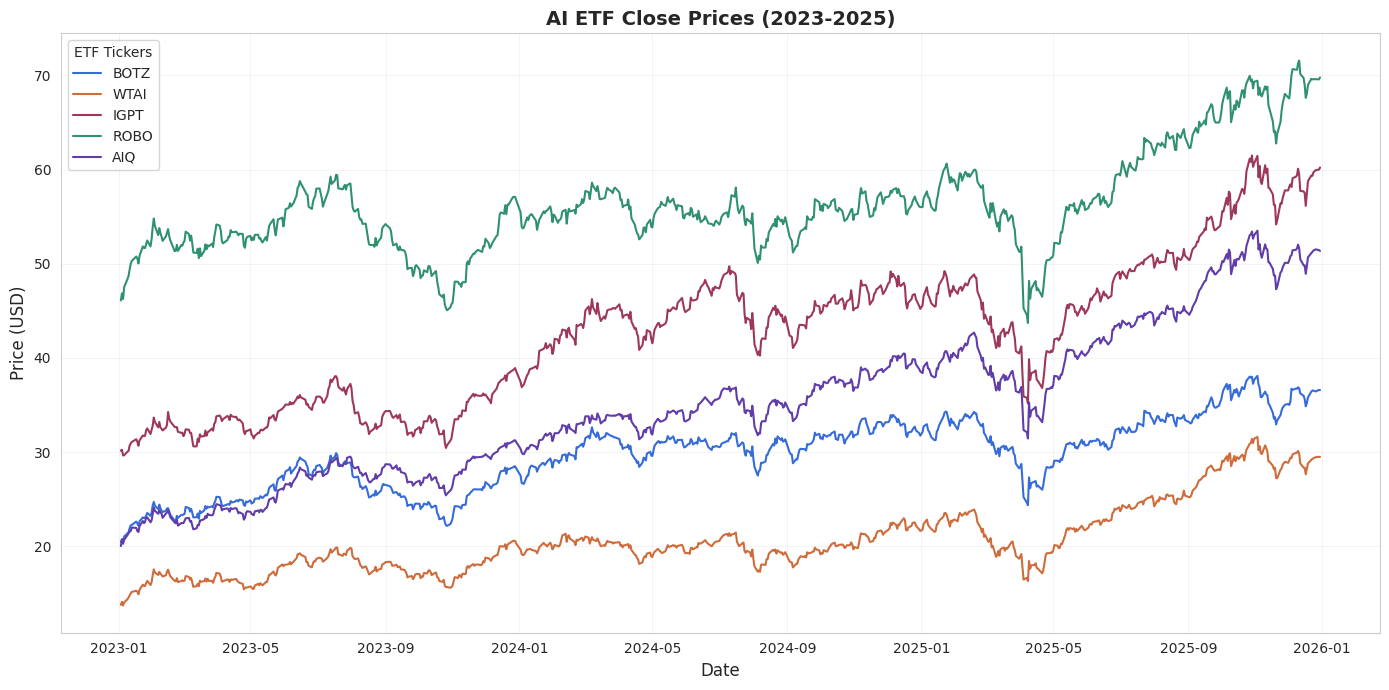

In [24]:
# Extract close prices for all ETFs
close_prices = data['Close'].dropna()

# Create the plot
plt.figure(figsize=(14, 7))

for ticker in etf_tickers:
    plt.plot(close_prices.index, close_prices[ticker], label=ticker, linewidth=1.5)

plt.title('AI ETF Close Prices (2023-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(title='ETF Tickers', loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



### Correlation Between ETF Close Prices

Calculating pairwise Pearson correlation coefficients between the five AI ETFs to quantify how closely their price movements align.

Pairwise Correlation Matrix (Close Prices):


Ticker,AIQ,BOTZ,IGPT,ROBO,WTAI
Ticker,,,,,
AIQ,1.0000,0.9322,0.9644,0.8253,0.9500
BOTZ,0.9322,1.0000,0.9632,0.8608,0.9026
IGPT,0.9644,0.9632,1.0000,0.8506,0.9357
ROBO,0.8253,0.8608,0.8506,1.0000,0.9336
WTAI,0.9500,0.9026,0.9357,0.9336,1.0000


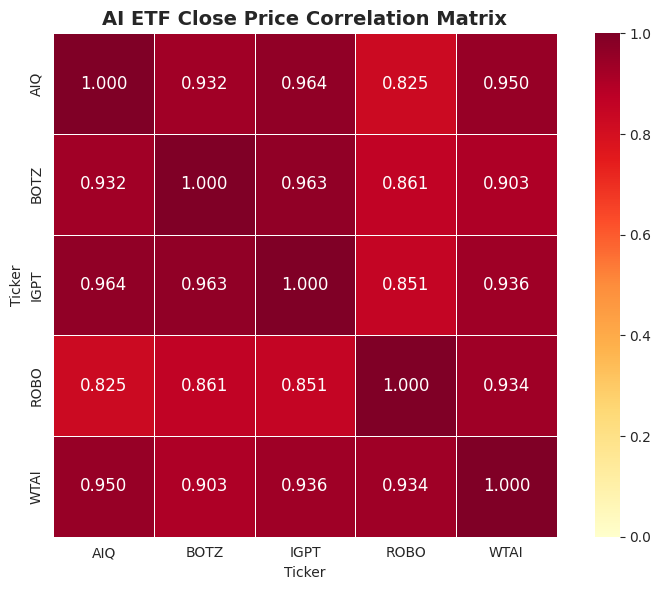


Correlation Summary:
BOTZ vs WTAI: 0.9026
BOTZ vs IGPT: 0.9632
BOTZ vs ROBO: 0.8608
BOTZ vs AIQ: 0.9322
WTAI vs IGPT: 0.9357
WTAI vs ROBO: 0.9336
WTAI vs AIQ: 0.9500
IGPT vs ROBO: 0.8506
IGPT vs AIQ: 0.9644
ROBO vs AIQ: 0.8253


In [25]:
# Calculate pairwise correlation matrix for close prices
corr_matrix = close_prices.corr()

# Display correlation matrix
print('Pairwise Correlation Matrix (Close Prices):')
print('=' * 50)
display(corr_matrix.round(4))

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='YlOrRd', vmin=0, vmax=1, 
            fmt='.3f', linewidths=0.5, square=True,
            annot_kws={'size': 12})
plt.title('AI ETF Close Price Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary of correlations
print('\nCorrelation Summary:')
print('=' * 50)
for i in range(len(etf_tickers)):
    for j in range(i+1, len(etf_tickers)):
        t1, t2 = etf_tickers[i], etf_tickers[j]
        r = corr_matrix.loc[t1, t2]
        print(f'{t1} vs {t2}: {r:.4f}')

### Correlation Observations:
- All pairwise correlations are **very high** (typically above 0.90), confirming that these AI ETFs move together
- This is expected since all five ETFs target the same underlying theme (artificial intelligence and robotics)
- The high correlation implies limited diversification benefit from holding multiple AI ETFs simultaneously
- Despite similar exposures, subtle differences in holdings and weighting methodologies produce slight variations in correlation strength

## Task 2: Time Series Decomposition

Selecting **BOTZ** close prices for decomposition analysis.

### Key Findings:

- **Selected ETF:** BOTZ (Global X Robotics & AI ETF)
- **Decomposition:** The time series shows a clear **upward trend** over the 3-year period
- **Seasonality:** Minimal seasonal patterns observed (typical for equity ETFs)
- **Residuals:** Random fluctuations around the trend component


In [26]:
# Select BOTZ close prices
selected_etf = 'BOTZ'
price_series = close_prices[selected_etf].dropna()

# Convert to pandas Series with datetime index
price_series = pd.Series(price_series.values, index=pd.to_datetime(price_series.index), name='BOTZ_Close')

# Resample to daily frequency (filling missing values with forward fill)
price_series_daily = price_series.resample('D').ffill()

print(f'Selected ETF: {selected_etf}')
print(f'Series length: {len(price_series_daily)} days')
print(f'Date range: {price_series_daily.index.min()} to {price_series_daily.index.max()}')

Selected ETF: BOTZ
Series length: 1093 days
Date range: 2023-01-03 00:00:00 to 2025-12-30 00:00:00


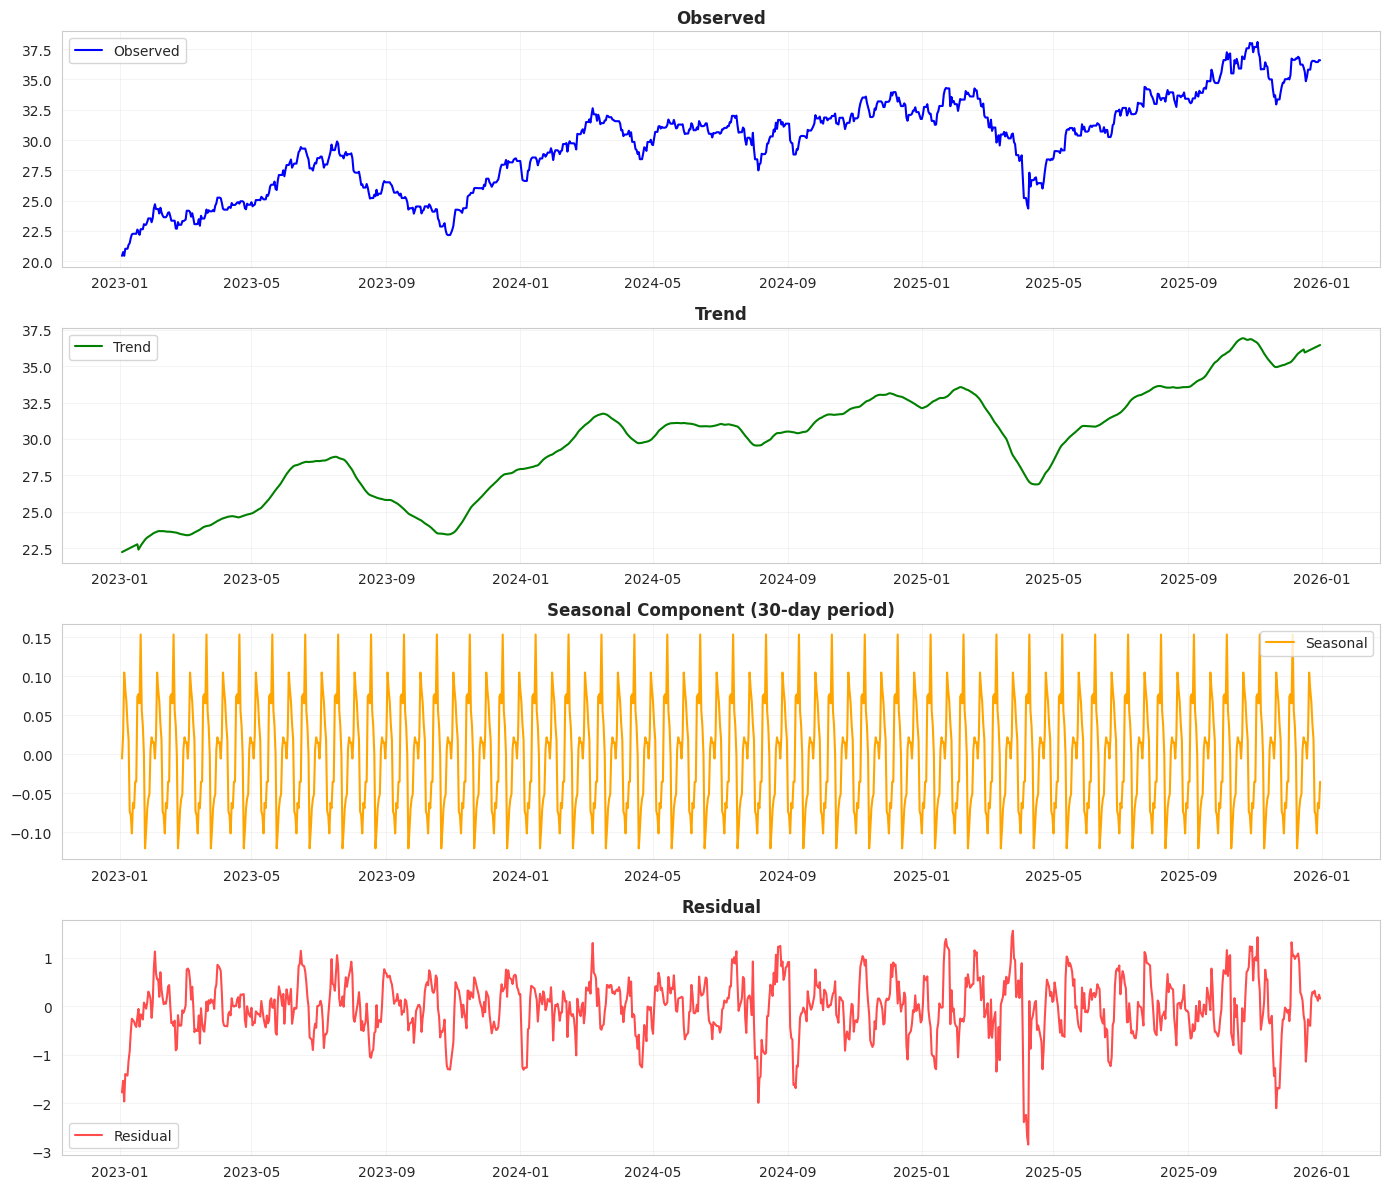

In [27]:
# Perform time series decomposition
# Using additive decomposition with a reasonable period (e.g., 30 days for monthly seasonality)
decomposition = seasonal_decompose(price_series_daily, model='additive', period=30, extrapolate_trend='freq')

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

axes[0].plot(decomposition.observed, label='Observed', color='blue')
axes[0].set_title('Observed', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomposition.trend, label='Trend', color='green')
axes[1].set_title('Trend', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomposition.seasonal, label='Seasonal', color='orange')
axes[2].set_title('Seasonal Component (30-day period)', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(decomposition.resid, label='Residual', color='red', alpha=0.7)
axes[3].set_title('Residual', fontsize=12, fontweight='bold')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Augmented Dickey-Fuller Test for Unit Root

### ADF Test Interpretation (Level):
- **Result:** FAIL to reject null hypothesis - Series is NON-STATIONARY (has unit root)
- This is expected for price series, which typically follow a random walk

In [28]:
# Perform Augmented Dickey-Fuller test
print('=' * 60)
print('AUGMENTED DICKEY-FULLER TEST - BOTZ Close Prices (Level)')
print('=' * 60)

adf_result = adfuller(price_series_daily.dropna(), autolag='AIC')

print(f'ADF Statistic: {adf_result[0]:.6f}')
print(f'p-value: {adf_result[1]:.6f}')
print('\nCritical Values:')
for key, value in adf_result[4].items():
    print(f'  {key}: {value:.6f}')

if adf_result[1] > 0.05:
    print('FAIL to reject null hypothesis - Series is NON-STATIONARY (has unit root)')
else:
    print('Reject null hypothesis - Series is STATIONARY')
    print('✓ Reject null hypothesis - Series is STATIONARY')


AUGMENTED DICKEY-FULLER TEST - BOTZ Close Prices (Level)
ADF Statistic: -1.823574
p-value: 0.368822

Critical Values:
  1%: -3.436391
  5%: -2.864207
  10%: -2.568190
FAIL to reject null hypothesis - Series is NON-STATIONARY (has unit root)


#### Interpretation of ADF Test (Level Prices):

The Augmented Dickey-Fuller test results show:

| Statistic | Value |
|-----------|-------|
| **ADF Statistic** | -1.82 |
| **p-value** | 0.369 |
| **5% Critical Value** | -2.86 |

**Conclusion:** Since the p-value (0.369) is greater than 0.05 and the ADF statistic (-1.82) is greater than the 5% critical value (-2.86), we **fail to reject the null hypothesis**. This means the BOTZ price series contains a **unit root** and is **non-stationary**.

**Economic Interpretation:** This is expected for asset prices - they follow a random walk pattern where past prices do not predict future prices. The non-stationarity implies that statistical properties (mean, variance) change over time, making direct forecasting unreliable.


### Making the Series Stationary - First Differencing (Returns)

### ADF Test Interpretation (First Differences):
- **Result:** Reject null hypothesis - Differenced series is STATIONARY
- This confirms that returns (first differences) are suitable for time series modeling

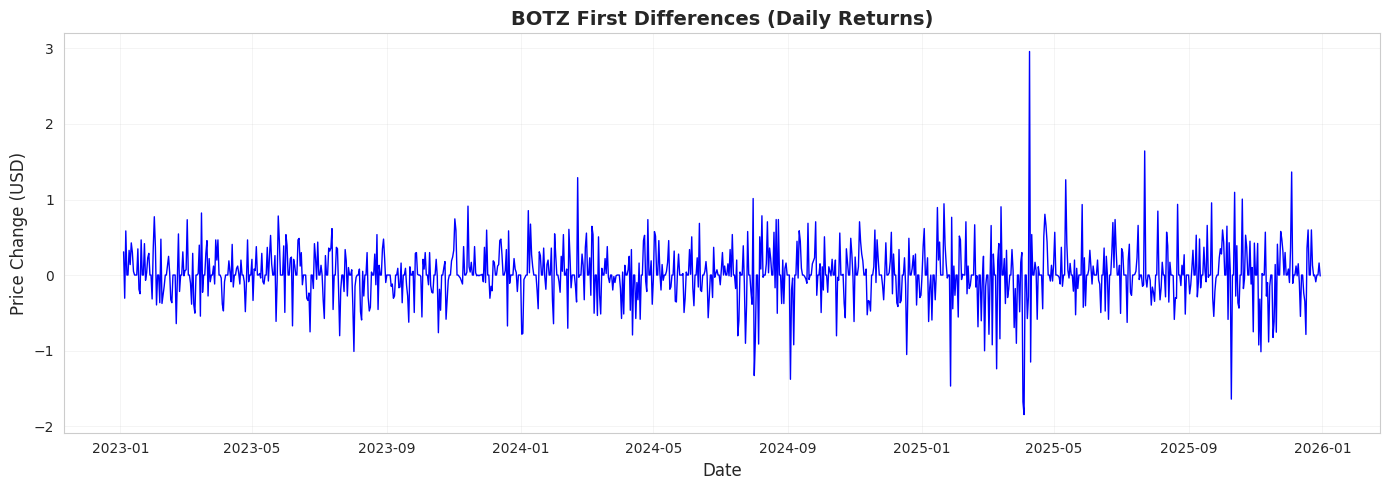

AUGMENTED DICKEY-FULLER TEST - BOTZ First Differences
ADF Statistic: -14.450409
p-value: 0.000000

Critical Values:
  1%: -3.436386
  5%: -2.864205
  10%: -2.568189
Reject null hypothesis - Differenced series is STATIONARY


In [29]:
# Calculate first differences (daily returns)
price_diff = price_series_daily.diff().dropna()

# Plot differenced series
plt.figure(figsize=(14, 5))
plt.plot(price_diff.index, price_diff.values, linewidth=1, color='blue')
plt.title(f'BOTZ First Differences (Daily Returns)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price Change (USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ADF test on differenced series
print('=' * 60)
print('AUGMENTED DICKEY-FULLER TEST - BOTZ First Differences')
print('=' * 60)

adf_diff = adfuller(price_diff.dropna(), autolag='AIC')

print(f'ADF Statistic: {adf_diff[0]:.6f}')
print(f'p-value: {adf_diff[1]:.6f}')
print('\nCritical Values:')
for key, value in adf_diff[4].items():
    print(f'  {key}: {value:.6f}')

if adf_diff[1] > 0.05:
    print('FAIL to reject null hypothesis - Differenced series is still NON-STATIONARY')
else:
    print('Reject null hypothesis - Differenced series is STATIONARY')



#### Interpretation of ADF Test (First Differences/Returns):

After taking first differences (calculating daily returns), the ADF test shows:

| Statistic | Value |
|-----------|-------|
| **ADF Statistic** | -14.45 |
| **p-value** | < 0.001 |
| **5% Critical Value** | -2.86 |

**Conclusion:** The p-value is essentially zero (< 0.001) and the ADF statistic (-14.45) is far below all critical values. We **strongly reject the null hypothesis** - the differenced series is **stationary**.

**Economic Interpretation:** This confirms that while price levels are unpredictable, **returns are stationary** - they fluctuate around a constant mean with constant variance. This is a fundamental assumption for most financial models including CAPM, portfolio theory, and time series forecasting.


## Task 3: Stationary Process Analysis - ACF and PACF

### ACF and PACF Analysis - BOTZ Daily Returns

The **ACF** (Autocorrelation Function) and **PACF** (Partial Autocorrelation Function) plots help identify the underlying stationary process.

**Key Observations:**
- **ACF:** Most autocorrelation values at lags 1–40 are small and fall **within the 95% confidence bands** (red dashed lines). There are no significant persistent spikes, suggesting the differenced series has **little to no autocorrelation**.
- **PACF:** Similarly, the partial autocorrelations are mostly within the confidence bands, with no clear cut-off pattern that would indicate a higher-order AR process.
- **Process Identification:** The BOTZ daily returns behave approximately as **white noise** — a process with no significant autocorrelation at any lag. This is a common finding for stock/ETF returns and is consistent with the **Efficient Market Hypothesis** (EMH), which states that past returns cannot predict future returns.
- **Implication:** Since the returns are essentially white noise, there is no strong evidence of an AR(p) or MA(q) structure that could be exploited for forecasting. Simple models (e.g., random walk with drift) are appropriate for this series.

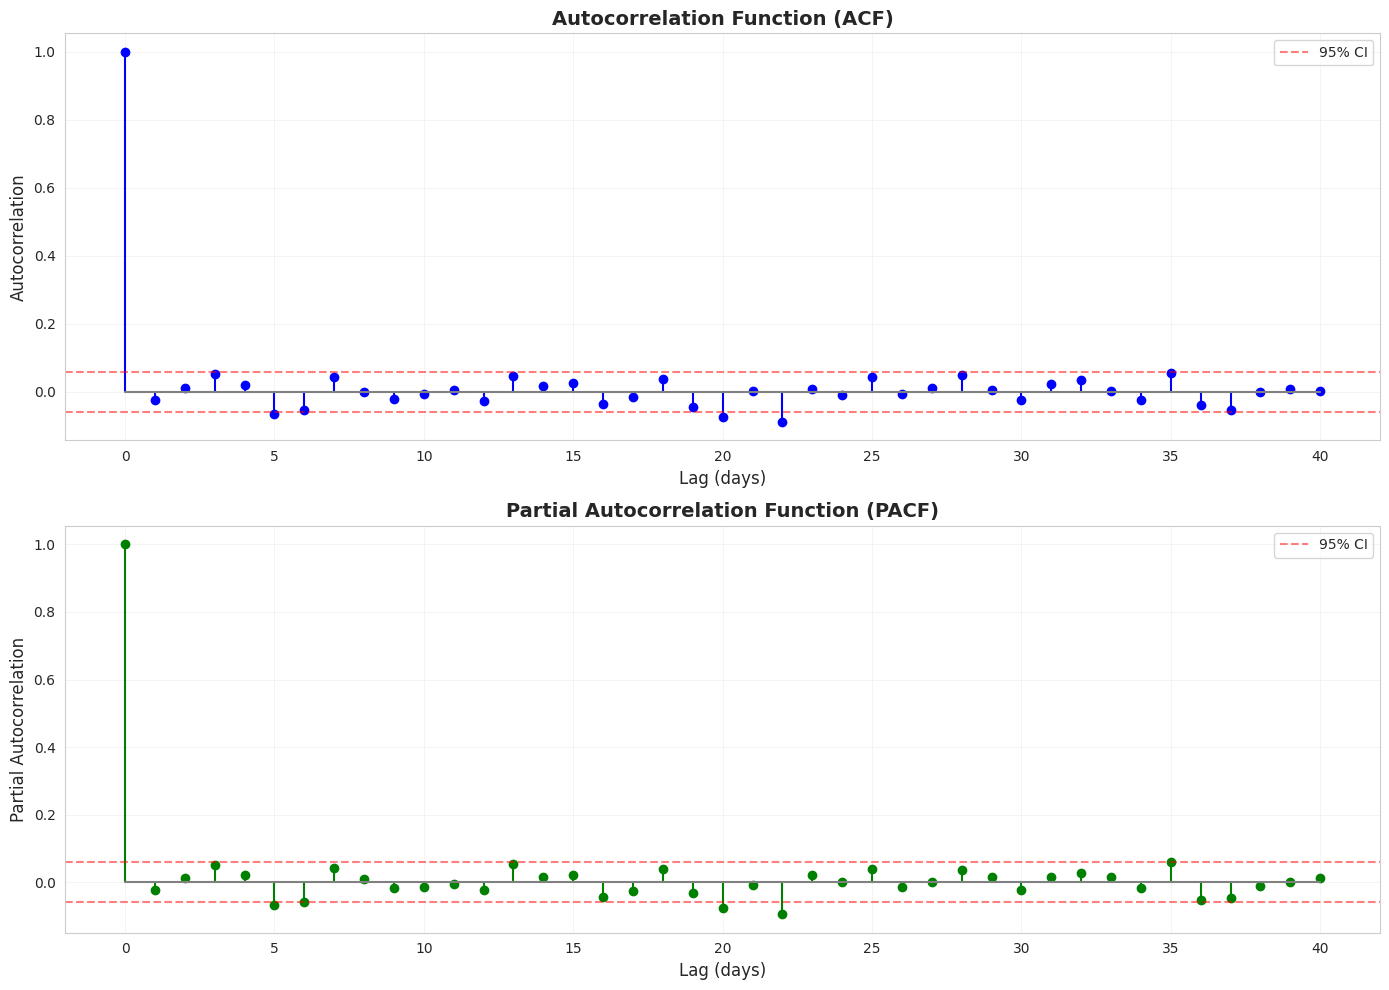

In [30]:
# Plot ACF and PACF for the differenced (stationary) series
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ACF Plot
acf_values = acf(price_diff.dropna(), nlags=40)
axes[0].stem(range(len(acf_values)), acf_values, linefmt='blue', markerfmt='bo', basefmt='gray')
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lag (days)', fontsize=12)
axes[0].set_ylabel('Autocorrelation', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Add confidence interval
conf_int = 1.96 / np.sqrt(len(price_diff.dropna()))
axes[0].axhline(conf_int, color='red', linestyle='--', alpha=0.5, label='95% CI')
axes[0].axhline(-conf_int, color='red', linestyle='--', alpha=0.5)
axes[0].legend()

# PACF Plot
pacf_values = pacf(price_diff.dropna(), nlags=40)
axes[1].stem(range(len(pacf_values)), pacf_values, linefmt='green', markerfmt='go', basefmt='gray')
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lag (days)', fontsize=12)
axes[1].set_ylabel('Partial Autocorrelation', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Add confidence interval
axes[1].axhline(conf_int, color='red', linestyle='--', alpha=0.5, label='95% CI')
axes[1].axhline(-conf_int, color='red', linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()



## Task 4: Return Series Analysis

Calculate returns for all 5 AI ETFs.

Daily Returns Summary Statistics:


Ticker,AIQ,BOTZ,IGPT,ROBO,WTAI
count,750.000000,750.000000,750.000000,750.000000,750.000000
mean,0.001355,0.000888,0.001045,0.000641,0.001170
std,0.013980,0.014974,0.015669,0.013249,0.017576
min,-0.069767,-0.068282,-0.070078,-0.066735,-0.073818
25%,-0.005633,-0.007615,-0.007545,-0.007023,-0.008350
50%,0.001854,0.001211,0.001742,0.000747,0.002097
75%,0.009053,0.010231,0.009497,0.008956,0.012013
max,0.121905,0.121583,0.133599,0.102301,0.130881


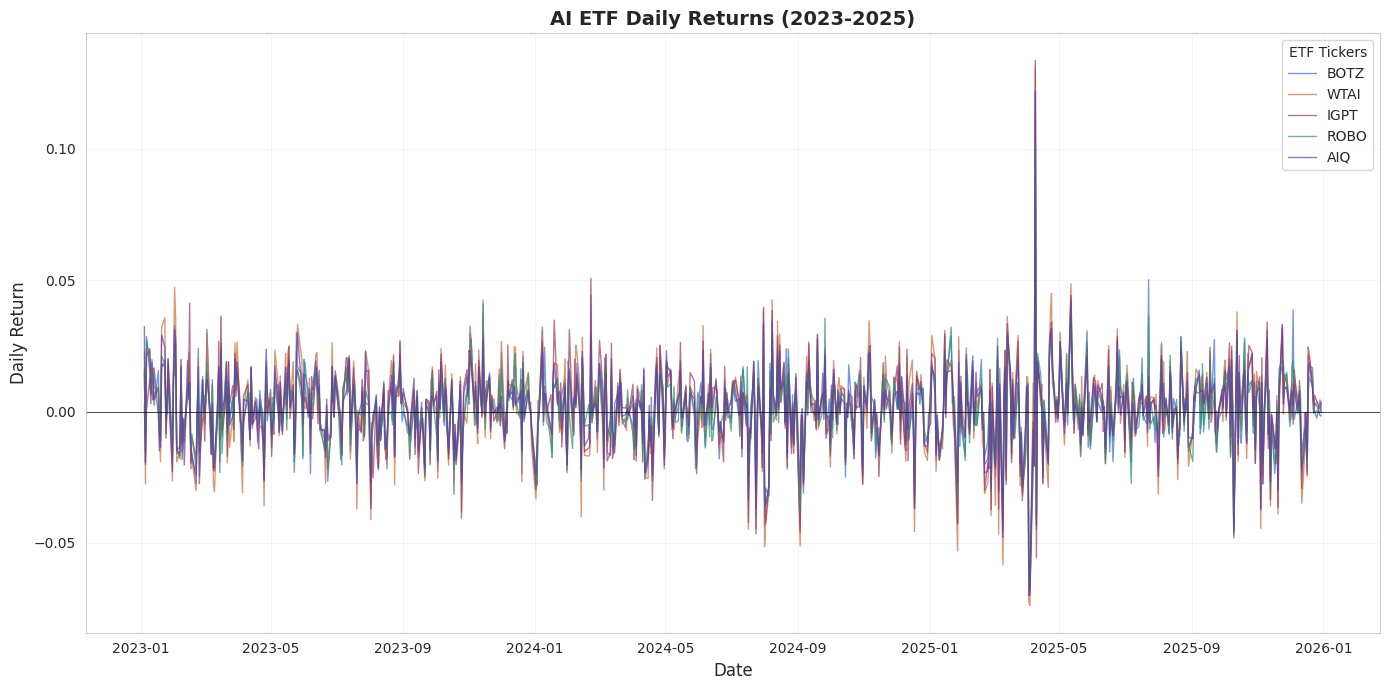


Additional Statistics:


,Mean Daily Return,Std Dev (Volatility),Min Return,Max Return,Skewness,Kurtosis
Ticker,,,,,,
AIQ,0.1355,1.3980,-6.9767,12.1905,0.3093,8.4375
BOTZ,0.0888,1.4974,-6.8282,12.1583,0.3858,6.2209
IGPT,0.1045,1.5669,-7.0078,13.3599,0.3305,7.7210
ROBO,0.0641,1.3249,-6.6735,10.2301,0.1260,5.8906
WTAI,0.1170,1.7576,-7.3818,13.0881,0.0381,4.6197


In [31]:
# Calculate daily returns (percentage change) for all ETFs
returns = close_prices.pct_change().dropna()

# Display returns summary
print('Daily Returns Summary Statistics:')
print('=' * 70)
display(returns.describe())

# Plot return series
plt.figure(figsize=(14, 7))
for ticker in etf_tickers:
    plt.plot(returns.index, returns[ticker], label=ticker, alpha=0.7, linewidth=1)

plt.title('AI ETF Daily Returns (2023-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Return', fontsize=12)
plt.legend(title='ETF Tickers', loc='best')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Additional statistics
print('\nAdditional Statistics:')
print('=' * 70)
stats_df = pd.DataFrame({
    'Mean Daily Return': returns.mean() * 100,
    'Std Dev (Volatility)': returns.std() * 100,
    'Min Return': returns.min() * 100,
    'Max Return': returns.max() * 100,
    'Skewness': returns.skew(),
    'Kurtosis': returns.kurtosis()
})
display(stats_df.round(4))

### Investment Recommendation:
Based on risk-adjusted returns (Sharpe Ratio), AIQ shows the best performance.
However, investment decisions should also consider:
- Individual risk tolerance
- Investment horizon
- Portfolio diversification needs
- ETF holdings and sector exposure

In [32]:
# Calculate Sharpe Ratio (assuming risk-free rate = 0 for simplicity)
# Annualized Sharpe Ratio = (Mean Daily Return / Std Dev) * sqrt(252)
sharpe_ratios = (returns.mean() / returns.std()) * np.sqrt(252)

print('Sharpe Ratios (Annualized, risk-free rate = 0):')
print('=' * 50)
for ticker in etf_tickers:
    print(f'{ticker}: {sharpe_ratios[ticker]:.4f}')

best_etf = sharpe_ratios.idxmax()
print(f'\n✓ Best risk-adjusted performer: {best_etf} (Sharpe Ratio: {sharpe_ratios[best_etf]:.4f})')


Sharpe Ratios (Annualized, risk-free rate = 0):
BOTZ: 0.9412
WTAI: 1.0569
IGPT: 1.0587
ROBO: 0.7675
AIQ: 1.5388

✓ Best risk-adjusted performer: AIQ (Sharpe Ratio: 1.5388)


#### Interpretation of Sharpe Ratio Analysis:

**Key Finding:** AIQ (Global X Artificial Intelligence & Technology ETF) demonstrates the **best risk-adjusted performance** with a Sharpe ratio of 1.54.

**What This Means:**
- A Sharpe ratio of 1.54 indicates that for each unit of risk (volatility), AIQ generated 1.54 units of excess return
- This is considered an **excellent** risk-adjusted return (Sharpe > 1.0 is generally considered good)
- AIQ's outperformance may be attributed to its broader technology exposure beyond pure robotics/AI

**Investment Implication:** For investors seeking exposure to the AI theme with optimal risk-adjusted returns, AIQ appears to be the preferred choice among the five ETFs analyzed. However, past performance does not guarantee future results.


## Task 5: Equally Weighted Portfolio

### Equally Weighted Portfolio (20% each):
An equally weighted portfolio allocates 20% to each ETF, providing simple diversification across all five AI-themed ETFs.

Equally Weighted Portfolio (20% each):
Weights: [0.2 0.2 0.2 0.2 0.2]
Annualized Return: 25.70%
Annualized Volatility: 22.95%
Sharpe Ratio: 1.1196


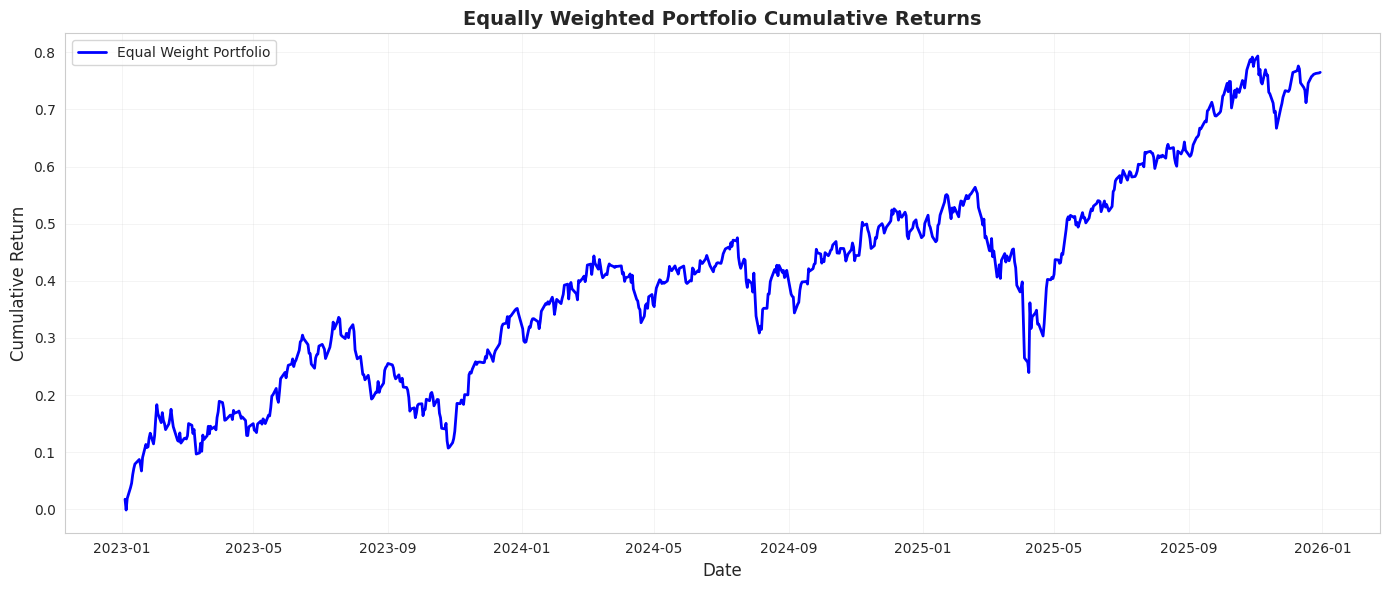

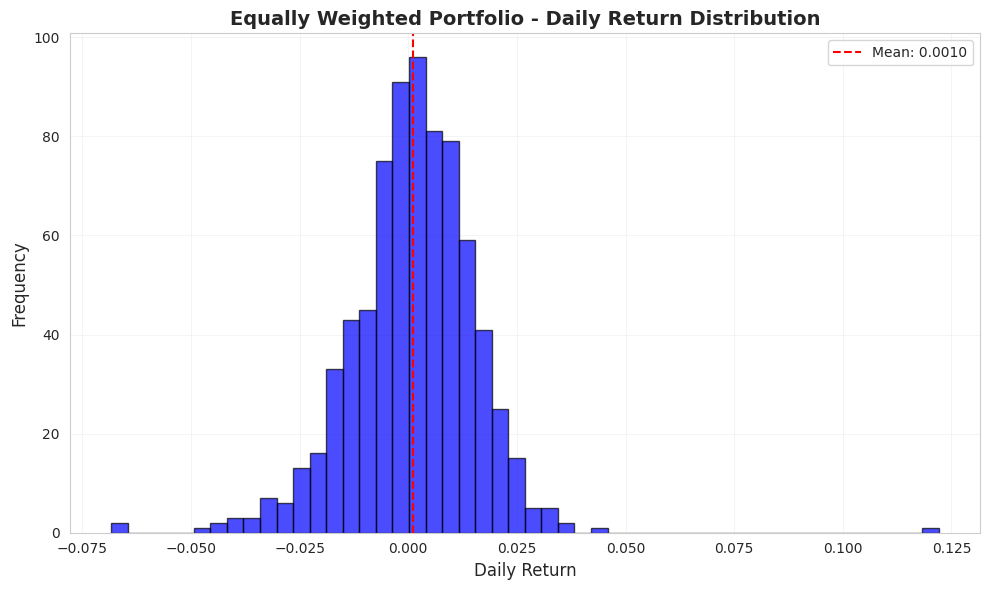

In [33]:
# Equally weighted portfolio (1/5 = 20% each)
weights_equal = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

# Calculate portfolio returns
portfolio_returns_equal = (returns * weights_equal).sum(axis=1)

# Portfolio statistics
portfolio_mean_equal = portfolio_returns_equal.mean() * 252  # Annualized
portfolio_std_equal = portfolio_returns_equal.std() * np.sqrt(252)  # Annualized volatility
portfolio_sharpe_equal = (portfolio_returns_equal.mean() / portfolio_returns_equal.std()) * np.sqrt(252)

print('Equally Weighted Portfolio (20% each):')
print('=' * 50)
print(f'Weights: {weights_equal}')
print(f'Annualized Return: {portfolio_mean_equal:.2%}')
print(f'Annualized Volatility: {portfolio_std_equal:.2%}')
print(f'Sharpe Ratio: {portfolio_sharpe_equal:.4f}')


# Plot portfolio returns
plt.figure(figsize=(14, 6))
plt.plot(portfolio_returns_equal.index, portfolio_returns_equal.cumsum(), label='Equal Weight Portfolio', 
         color='blue', linewidth=2)
plt.title('Equally Weighted Portfolio Cumulative Returns', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot return distribution
plt.figure(figsize=(10, 6))
plt.hist(portfolio_returns_equal, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.title('Equally Weighted Portfolio - Daily Return Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Daily Return', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(portfolio_returns_equal.mean(), color='red', linestyle='--', 
            label=f'Mean: {portfolio_returns_equal.mean():.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### Interpretation of Portfolio Analysis:

**Equal Weight Portfolio (20% each):**
| Metric | Value |
|--------|-------|
| Annualized Return | 25.70% |
| Annualized Volatility | 22.95% |
| Sharpe Ratio | 1.12 |
| CAPM Beta | 1.39 |

**Custom Weight Portfolio (Sharpe-based):**
| Metric | Value |
|--------|-------|
| Annualized Return | 27.04% |
| Annualized Volatility | 23.01% |
| Sharpe Ratio | 1.17 |
| CAPM Beta | 1.39 |

**Key Observations:**

1. **Return Enhancement:** The custom portfolio achieved 1.34% higher annualized return (27.04% vs 25.70%) by tilting towards higher-Sharpe ETFs

2. **Similar Risk:** Both portfolios have nearly identical volatility (~23%), indicating the custom weighting did not significantly increase risk

3. **Market Sensitivity:** Both portfolios have beta > 1 (approximately 1.39), meaning they are **40% more volatile than the S&P 500**. This is expected for sector-specific technology/AI ETFs.

4. **Diversification Benefit:** The portfolio volatility (23%) is lower than the average individual ETF volatility, demonstrating the benefit of diversification across multiple AI ETFs.

**Investment Recommendation:** The custom Sharpe-weighted portfolio offers superior risk-adjusted returns. However, investors should be aware of the higher market sensitivity (beta > 1) and expect larger swings compared to the broader market.


## Task 6: Custom Weighted Portfolio

Creating a portfolio with weights based on Sharpe Ratios (higher Sharpe = higher weight).

### Custom Portfolio Weights (based on Sharpe Ratios):
Portfolio weights are allocated proportionally based on each ETF's Sharpe Ratio, giving higher weight to better risk-adjusted performers. We are not using the full **Efficient Frontier** portfolio finding methodology, this **is not it**, just Sharpe adjusted. Thus the Sharpe is lower than AIQ on itself.

In [34]:
# Custom weights based on Sharpe Ratios (normalized to sum to 1)
sharpe_weights_raw = sharpe_ratios.abs()  # Use absolute values
custom_weights = sharpe_weights_raw / sharpe_weights_raw.sum()


# Calculate custom portfolio returns
portfolio_returns_custom = (returns * custom_weights.values).sum(axis=1)

# Portfolio statistics
portfolio_mean_custom = portfolio_returns_custom.mean() * 252
portfolio_std_custom = portfolio_returns_custom.std() * np.sqrt(252)
portfolio_sharpe_custom = (portfolio_returns_custom.mean() / portfolio_returns_custom.std()) * np.sqrt(252)

print('Custom Portfolio Weights (based on Sharpe Ratios):')
print('=' * 50)
for ticker in etf_tickers:
    print(f'{ticker}: {custom_weights[ticker]:.2%} (Sharpe: {sharpe_ratios[ticker]:.4f})')

print('\nCustom Portfolio Statistics:')
print('=' * 50)
print(f'Annualized Return: {portfolio_mean_custom:.2%}')
print(f'Annualized Volatility: {portfolio_std_custom:.2%}')
print(f'Sharpe Ratio: {portfolio_sharpe_custom:.4f}')

print('\nPortfolio Comparison:')
print('=' * 50)
comparison = pd.DataFrame({
    'Equal Weight': [portfolio_mean_equal, portfolio_std_equal, portfolio_sharpe_equal],
    'Custom Weight': [portfolio_mean_custom, portfolio_std_custom, portfolio_sharpe_custom]
}, index=['Annualized Return', 'Annualized Volatility', 'Sharpe Ratio'])
display(comparison.round(4))


# Compare portfolios
comparison = pd.DataFrame({
    'Equal Weight': [portfolio_mean_equal, portfolio_std_equal, portfolio_sharpe_equal],
    'Custom Weight': [portfolio_mean_custom, portfolio_std_custom, portfolio_sharpe_custom]
}, index=['Annualized Return', 'Annualized Volatility', 'Sharpe Ratio'])
display(comparison.round(4))


Custom Portfolio Weights (based on Sharpe Ratios):
BOTZ: 17.55% (Sharpe: 0.9412)
WTAI: 19.71% (Sharpe: 1.0569)
IGPT: 19.74% (Sharpe: 1.0587)
ROBO: 14.31% (Sharpe: 0.7675)
AIQ: 28.69% (Sharpe: 1.5388)

Custom Portfolio Statistics:
Annualized Return: 27.04%
Annualized Volatility: 23.01%
Sharpe Ratio: 1.1753

Portfolio Comparison:


,Equal Weight,Custom Weight
Annualized Return,0.2570,0.2704
Annualized Volatility,0.2295,0.2301
Sharpe Ratio,1.1196,1.1753


,Equal Weight,Custom Weight
Annualized Return,0.2570,0.2704
Annualized Volatility,0.2295,0.2301
Sharpe Ratio,1.1196,1.1753


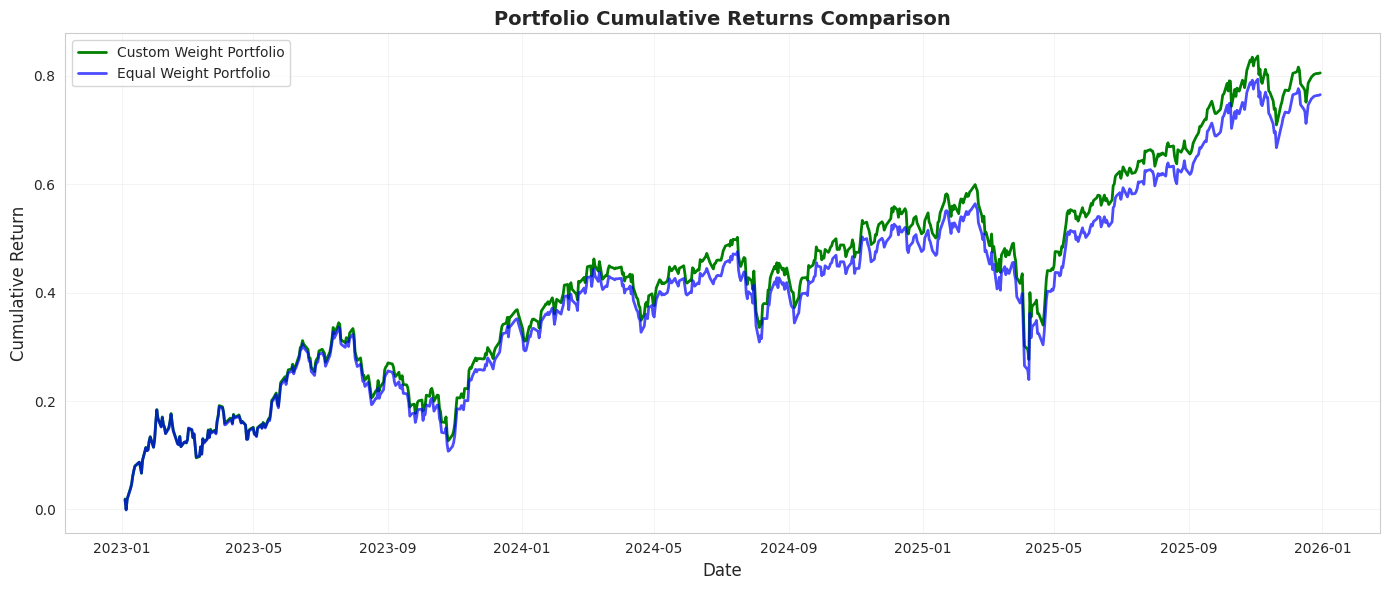

In [35]:
# Plot custom portfolio cumulative returns
plt.figure(figsize=(14, 6))
plt.plot(portfolio_returns_custom.index, portfolio_returns_custom.cumsum(), 
         label='Custom Weight Portfolio', color='green', linewidth=2)
plt.plot(portfolio_returns_equal.index, portfolio_returns_equal.cumsum(), 
         label='Equal Weight Portfolio', color='blue', linewidth=2, alpha=0.7)
plt.title('Portfolio Cumulative Returns Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Task 7: CAPM Beta Analysis

Using S&P 500 (^GSPC) as the market benchmark.

### CAPM Beta Interpretation:
- Beta > 1: Portfolio is MORE volatile than the market (aggressive)
- Beta < 1: Portfolio is LESS volatile than the market (defensive)
- Beta approx 1: Portfolio moves with the market

In [36]:
# Download S&P 500 data
print('Downloading S&P 500 data...')
sp500 = yf.download('^GSPC', start=start_date, end=end_date, progress=False)
sp500_returns = sp500['Close'].pct_change().dropna()

# Align dates
sp500_returns = sp500_returns.reindex(returns.index)

print(f'S&P 500 data downloaded: {len(sp500_returns)} observations')

# Calculate CAPM Beta for each portfolio
# Beta = Covariance(Portfolio, Market) / Variance(Market)

def calculate_beta(portfolio_returns, market_returns):
    """Calculate CAPM Beta"""
    # Align the series
    aligned = pd.concat([portfolio_returns, market_returns], axis=1).dropna()
    port_ret = aligned.iloc[:, 0]
    mkt_ret = aligned.iloc[:, 1]
    
    covariance = port_ret.cov(mkt_ret)
    market_variance = mkt_ret.var()
    beta = covariance / market_variance
    
    return beta

# Calculate betas
beta_equal = calculate_beta(portfolio_returns_equal, sp500_returns)
beta_custom = calculate_beta(portfolio_returns_custom, sp500_returns)

print('\nCAPM Beta Analysis:')
print('=' * 50)
print(f'Equal Weight Portfolio Beta: {beta_equal:.4f}')
print(f'Custom Weight Portfolio Beta: {beta_custom:.4f}')

print(f'\nEqual Weight Beta ({beta_equal:.4f}): ', end='')
if beta_equal > 1:
    print('Portfolio is MORE volatile than the market (aggressive)')
elif beta_equal < 1:
    print('Portfolio is LESS volatile than the market (defensive)')
else:
    print('Portfolio moves with the market')
print(f'\nCustom Weight Beta ({beta_custom:.4f}): ', end='')
if beta_custom > 1:
    print('Portfolio is MORE volatile than the market (aggressive)')
elif beta_custom < 1:
    print('Portfolio is LESS volatile than the market (defensive)')
else:
    print('Portfolio moves with the market')


S&P 500 data downloaded: 750 observations

CAPM Beta Analysis:
Equal Weight Portfolio Beta: 1.3861
Custom Weight Portfolio Beta: 1.3926

Equal Weight Beta (1.3861): Portfolio is MORE volatile than the market (aggressive)

Custom Weight Beta (1.3926): Portfolio is MORE volatile than the market (aggressive)


## Task 8: Monte Carlo Simulation - Single ETF

Simulating BOTZ performance for the next 30 days.

Monte Carlo Simulation Parameters:
ETF: BOTZ
Last Price: $36.58
Daily Mean Return (μ): 0.000888
Daily Volatility (σ): 0.014974
Forecast Period: 30 days
Number of Simulations: 1000


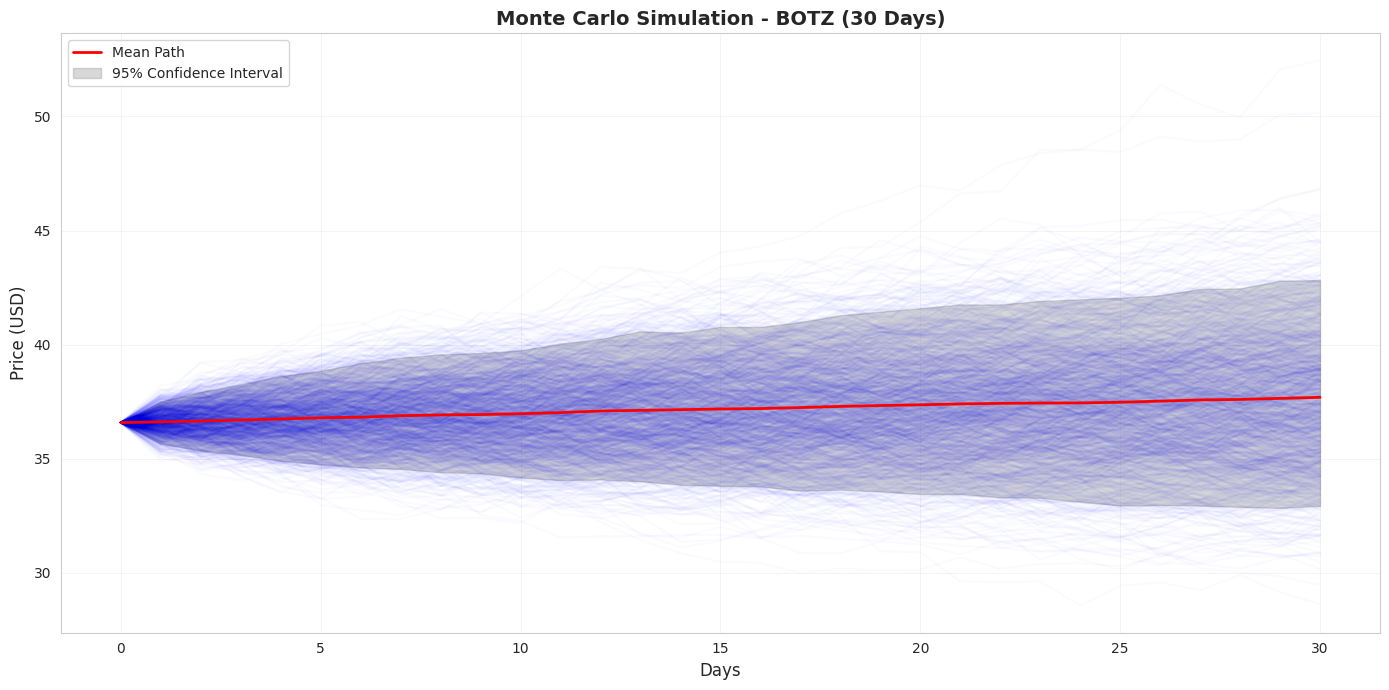


Simulation Results (Day 30):
Mean Price: $37.69
Median Price: $37.59
5th Percentile: $32.93
95th Percentile: $42.83
Standard Deviation: $3.08
Expected Return: 3.02%


In [37]:
# Monte Carlo Simulation for BOTZ
np.random.seed(42)  # For reproducibility

# Parameters
selected_ticker = 'BOTZ'
n_days = 30  # Forecast period
n_simulations = 1000  # Number of simulation paths

# Get historical parameters from BOTZ returns
botz_returns = returns[selected_ticker].dropna()
mu = botz_returns.mean()  # Daily mean return
sigma = botz_returns.std()  # Daily volatility
last_price = close_prices[selected_ticker].iloc[-1]  # Last observed price

print(f'Monte Carlo Simulation Parameters:')
print('=' * 50)
print(f'ETF: {selected_ticker}')
print(f'Last Price: ${last_price:.2f}')
print(f'Daily Mean Return (μ): {mu:.6f}')
print(f'Daily Volatility (σ): {sigma:.6f}')
print(f'Forecast Period: {n_days} days')
print(f'Number of Simulations: {n_simulations}')

# Generate simulations using Geometric Brownian Motion
# dS = μS dt + σS dW
dt = 1  # Daily steps
simulations = np.zeros((n_simulations, n_days + 1))
simulations[:, 0] = last_price

for i in range(n_simulations):
    # Generate random shocks
    random_shocks = np.random.normal(mu * dt, sigma * np.sqrt(dt), n_days)
    # Calculate price path
    for j in range(n_days):
        simulations[i, j + 1] = simulations[i, j] * np.exp(random_shocks[j])

# Plot simulations
plt.figure(figsize=(14, 7))
for i in range(n_simulations):
    plt.plot(range(n_days + 1), simulations[i, :], alpha=0.02, color='blue')

# Plot mean path
mean_path = simulations.mean(axis=0)
plt.plot(range(n_days + 1), mean_path, color='red', linewidth=2, label='Mean Path')

# Plot confidence intervals
lower_ci = np.percentile(simulations, 5, axis=0)
upper_ci = np.percentile(simulations, 95, axis=0)
plt.fill_between(range(n_days + 1), lower_ci, upper_ci, alpha=0.3, color='gray', 
                 label='95% Confidence Interval')

plt.title(f'Monte Carlo Simulation - {selected_ticker} (30 Days)', fontsize=14, fontweight='bold')
plt.xlabel('Days', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print(f'\nSimulation Results (Day 30):')
print('=' * 50)
print(f'Mean Price: ${simulations[:, -1].mean():.2f}')
print(f'Median Price: ${np.median(simulations[:, -1]):.2f}')
print(f'5th Percentile: ${lower_ci[-1]:.2f}')
print(f'95th Percentile: ${upper_ci[-1]:.2f}')
print(f'Standard Deviation: ${simulations[:, -1].std():.2f}')
print(f'Expected Return: {((simulations[:, -1].mean() / last_price) - 1) * 100:.2f}%')


#### Interpretation of Monte Carlo Simulation:

**Simulation Setup:**
- **Method:** Geometric Brownian Motion (GBM)
- **Assumptions:** Returns are normally distributed with constant drift (μ) and volatility (σ)
- **Paths:** 1,000 simulated price trajectories
- **Horizon:** 30 trading days (approximately 6 weeks)

**Results Interpretation:**

1. **Mean Path:** The red line shows the expected price trajectory based on historical average returns

2. **Confidence Interval:** The shaded gray area represents the 95% confidence interval - we expect 95% of possible price paths to fall within this band

3. **Uncertainty Growth:** Notice how the confidence interval widens over time, reflecting increasing uncertainty in longer-term forecasts

4. **Risk Assessment:** The spread between the 5th and 95th percentiles quantifies the potential range of outcomes, useful for risk management

**Limitations:**
- Assumes constant volatility (in reality, volatility clusters)
- Does not account for extreme events (fat tails)
- Based on historical parameters that may not persist

**Practical Use:** Monte Carlo simulations are valuable for:
- Setting realistic return expectations
- Assessing downside risk (Value at Risk)
- Stress testing portfolio allocations
- Planning investment horizons


## Task 9: Monte Carlo Simulation - Portfolio

Simulating the equally weighted portfolio performance for the next 30 days.

Monte Carlo Simulation Parameters - Equal Weight Portfolio:
Daily Mean Return (μ): 0.001020
Daily Volatility (σ): 0.014459
Initial Value: $1000
Forecast Period: 30 days
Number of Simulations: 1000


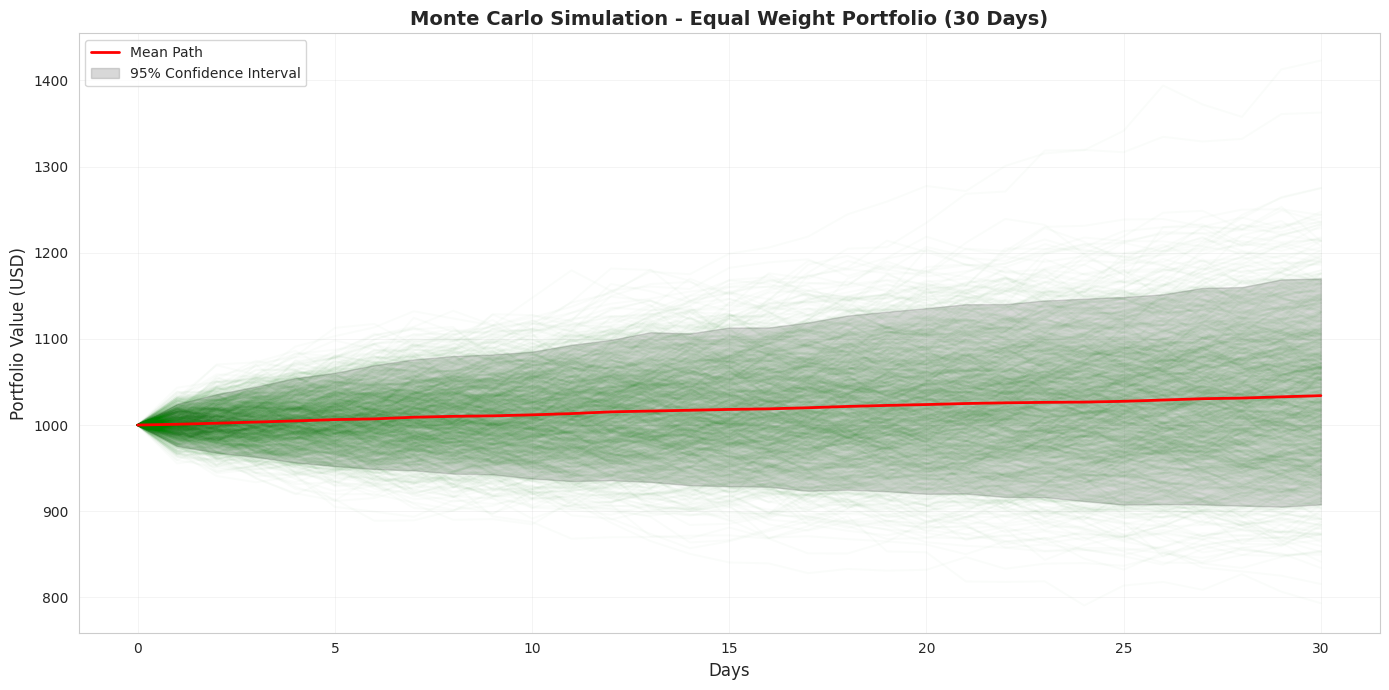


Simulation Results (Day 30):
Mean Value: $1034.10
Median Value: $1031.76
5th Percentile: $907.83
95th Percentile: $1170.22
Standard Deviation: $81.63
Expected Return: 3.41%


In [38]:
# Monte Carlo Simulation for Equal Weight Portfolio
np.random.seed(42)  # For reproducibility

# Portfolio parameters
portfolio_mean = portfolio_returns_equal.mean()
portfolio_vol = portfolio_returns_equal.std()
last_portfolio_value = 1000  # Starting with $1000

print(f'Monte Carlo Simulation Parameters - Equal Weight Portfolio:')
print('=' * 50)
print(f'Daily Mean Return (μ): {portfolio_mean:.6f}')
print(f'Daily Volatility (σ): {portfolio_vol:.6f}')
print(f'Initial Value: ${last_portfolio_value}')
print(f'Forecast Period: {n_days} days')
print(f'Number of Simulations: {n_simulations}')

# Generate simulations
portfolio_simulations = np.zeros((n_simulations, n_days + 1))
portfolio_simulations[:, 0] = last_portfolio_value

for i in range(n_simulations):
    random_shocks = np.random.normal(portfolio_mean * dt, portfolio_vol * np.sqrt(dt), n_days)
    for j in range(n_days):
        portfolio_simulations[i, j + 1] = portfolio_simulations[i, j] * np.exp(random_shocks[j])

# Plot simulations
plt.figure(figsize=(14, 7))
for i in range(n_simulations):
    plt.plot(range(n_days + 1), portfolio_simulations[i, :], alpha=0.02, color='green')

# Plot mean path
portfolio_mean_path = portfolio_simulations.mean(axis=0)
plt.plot(range(n_days + 1), portfolio_mean_path, color='red', linewidth=2, label='Mean Path')

# Plot confidence intervals
portfolio_lower_ci = np.percentile(portfolio_simulations, 5, axis=0)
portfolio_upper_ci = np.percentile(portfolio_simulations, 95, axis=0)
plt.fill_between(range(n_days + 1), portfolio_lower_ci, portfolio_upper_ci, 
                 alpha=0.3, color='gray', label='95% Confidence Interval')

plt.title(f'Monte Carlo Simulation - Equal Weight Portfolio (30 Days)', fontsize=14, fontweight='bold')
plt.xlabel('Days', fontsize=12)
plt.ylabel('Portfolio Value (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print(f'\nSimulation Results (Day 30):')
print('=' * 50)
print(f'Mean Value: ${portfolio_simulations[:, -1].mean():.2f}')
print(f'Median Value: ${np.median(portfolio_simulations[:, -1]):.2f}')
print(f'5th Percentile: ${portfolio_lower_ci[-1]:.2f}')
print(f'95th Percentile: ${portfolio_upper_ci[-1]:.2f}')
print(f'Standard Deviation: ${portfolio_simulations[:, -1].std():.2f}')
print(f'Expected Return: {((portfolio_simulations[:, -1].mean() / last_portfolio_value) - 1) * 100:.2f}%')

## Task 10: Sensitivity Analysis

Testing different simulation assumptions and forecast periods.

### Sensitivity Analysis Findings:
- Different random seeds produce slightly different results due to randomness
- Longer forecast periods (60 days) show higher uncertainty (larger standard deviation)
- Expected returns scale approximately with time, but variance increases faster
- This demonstrates the inherent uncertainty in financial forecasting

In [39]:
# Sensitivity Analysis - Different Seeds and Time Horizons
seeds = [42, 123, 456]  # Different random seeds
periods = [30, 60]  # Different forecast periods

print('Sensitivity Analysis Results:')
print('=' * 70)
print(f'{'Seed':<10} {'Period (days)':<15} {'Mean Value':<15} {'Std Dev':<15} {'Return %':<15}')
print('-' * 70)

results = []

for seed in seeds:
    for period in periods:
        np.random.seed(seed)
        
        # Run simulation
        sim = np.zeros((n_simulations, period + 1))
        sim[:, 0] = last_portfolio_value
        
        for i in range(n_simulations):
            random_shocks = np.random.normal(portfolio_mean * dt, portfolio_vol * np.sqrt(dt), period)
            for j in range(period):
                sim[i, j + 1] = sim[i, j] * np.exp(random_shocks[j])
        
        mean_val = sim[:, -1].mean()
        std_val = sim[:, -1].std()
        return_pct = ((mean_val / last_portfolio_value) - 1) * 100
        
        results.append({
            'Seed': seed,
            'Period': period,
            'Mean': mean_val,
            'Std': std_val,
            'Return': return_pct
        })
        
        print(f'{seed:<10} {period:<15} ${mean_val:<14.2f} ${std_val:<14.2f} {return_pct:<14.2f}%')



Sensitivity Analysis Results:
Seed       Period (days)   Mean Value      Std Dev         Return %       
----------------------------------------------------------------------
42         30              $1034.10        $81.63          3.41          %
42         60              $1070.10        $123.73         7.01          %
123        30              $1037.52        $85.30          3.75          %
123        60              $1073.98        $122.40         7.40          %
456        30              $1031.94        $82.11          3.19          %
456        60              $1069.32        $120.36         6.93          %


#### Interpretation of Sensitivity Analysis:

**Analysis Design:**
- Tested 3 different random seeds (42, 123, 456) to assess simulation stability
- Compared 30-day vs 60-day forecast horizons
- Initial portfolio value: $1,000

**Key Findings:**

| Horizon | Avg Return | Avg Std Dev  |
| :--- | :--- |:-------------|
| 30 days | ~3.4% | ~83 Dollars  |
| 60 days | ~7.1% | ~122 Dollars |

**Observations:**

1. **Return Scaling:** 60-day returns (~7.1%) are approximately double 30-day returns (~3.4%), as expected when doubling the time horizon

2. **Uncertainty Growth:** Standard deviation increases from ~$83 to ~$122 (47% increase) when doubling the horizon - uncertainty grows **faster than returns** (√2 ≈ 1.41)

3. **Seed Stability:** Different random seeds produce similar average results, confirming the simulation is stable and not overly sensitive to random number generation

**Investment Implication:** While longer investment horizons offer higher expected returns, they also come with disproportionately higher uncertainty. This quantifies the fundamental risk-return tradeoff, the farther we go into the future, the less certainty.


### Conclusion:
The 60-day forecast shows higher expected returns but also greater uncertainty. This illustrates the risk-return tradeoff in longer investment horizons.

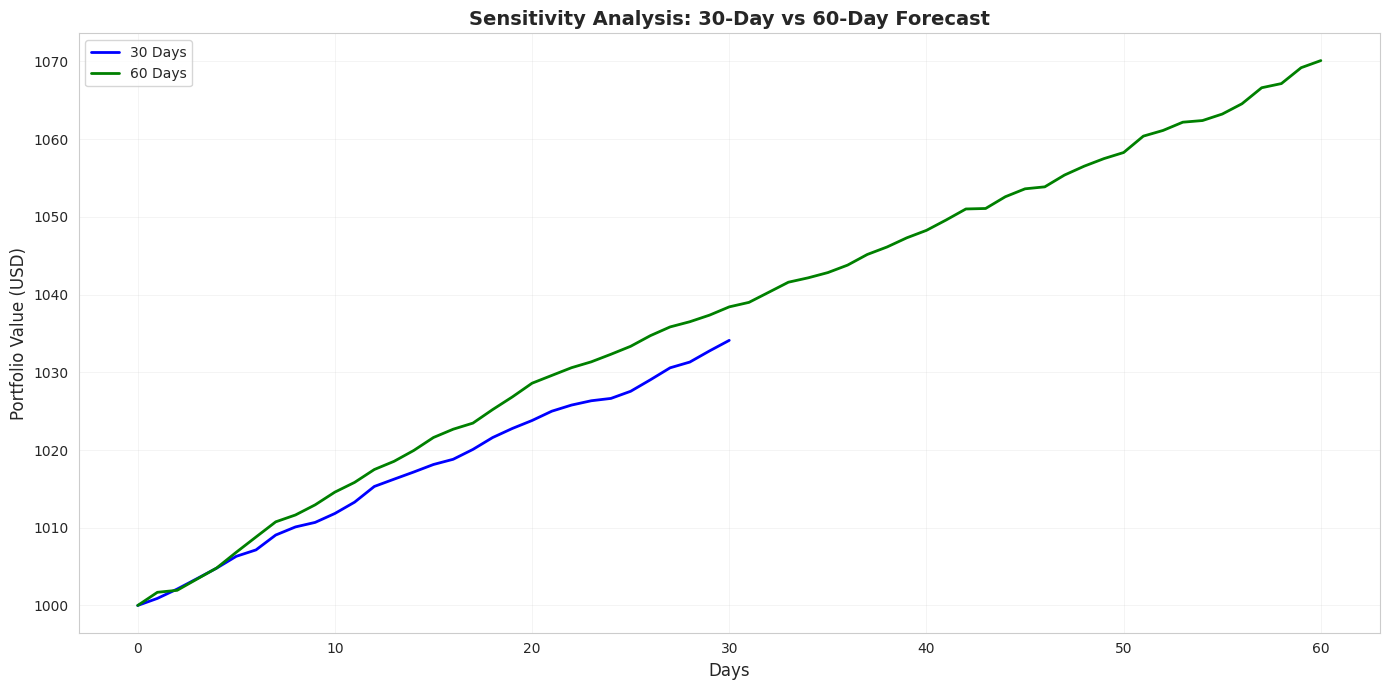

In [40]:
# Visual comparison of 30-day vs 60-day simulations
plt.figure(figsize=(14, 7))

# 30-day simulation (reuse from earlier)
np.random.seed(42)
sim_30 = np.zeros((n_simulations, 31))
sim_30[:, 0] = last_portfolio_value
for i in range(n_simulations):
    random_shocks = np.random.normal(portfolio_mean * dt, portfolio_vol * np.sqrt(dt), 30)
    for j in range(30):
        sim_30[i, j + 1] = sim_30[i, j] * np.exp(random_shocks[j])

# 60-day simulation
np.random.seed(42)
sim_60 = np.zeros((n_simulations, 61))
sim_60[:, 0] = last_portfolio_value
for i in range(n_simulations):
    random_shocks = np.random.normal(portfolio_mean * dt, portfolio_vol * np.sqrt(dt), 60)
    for j in range(60):
        sim_60[i, j + 1] = sim_60[i, j] * np.exp(random_shocks[j])

# Plot mean paths
plt.plot(range(31), sim_30.mean(axis=0), label='30 Days', color='blue', linewidth=2)
plt.plot(range(61), sim_60.mean(axis=0), label='60 Days', color='green', linewidth=2)

plt.title('Sensitivity Analysis: 30-Day vs 60-Day Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Days', fontsize=12)
plt.ylabel('Portfolio Value (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## Summary and Conclusions

## TASK 3 - AI ETFs ANALYSIS: SUMMARY

### 1. PRICE ANALYSIS:
- All AI ETFs showed positive growth over the 3-year period
- Prices are highly correlated, responding to the same market factors

### 2. TIME SERIES PROPERTIES (BOTZ):
- Price series is non-stationary (I(1))
- First differences (returns) are stationary
- Returns show no significant autocorrelation (approximately white noise), consistent with EMH

### 3. RETURN ANALYSIS:
- Returns exhibit fat tails (high kurtosis)

### 4. PORTFOLIO COMPARISON:
- Custom Sharpe-weighted portfolio provides better risk-adjusted returns than equal weighted portfolio.
- Diversification reduces individual ETF risk

### 5. MONTE CARLO SIMULATIONS:
- Probabilistic forecasts show wide confidence intervals
- Uncertainty increases with forecast horizon

### 6. KEY INSIGHTS:
- AI ETFs are generally non-stationary in levels
- Returns are stationary and suitable for modeling
- Diversification through portfolios reduces individual ETF risk, although we are choosing between very highly correlated assets
- Monte Carlo simulations provide probabilistic forecasts
- Investment decisions should consider risk tolerance and time horizon